In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import spikeinterface as si
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm
import umap

import sys
import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre


import torch.nn.functional as F
from pathlib import Path


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import time
import pickle
import networkx as nx
from scipy.spatial import ConvexHull
# from function.Function import *

In [2]:
def count_array2_in_range_of_array1(array1, array2, threshold=5):

    sorted_array1 = np.sort(array1)
    array2 = np.sort(array2)
    
    lefts = array2 - threshold
    rights = array2 + threshold
    
    left_indices = np.searchsorted(sorted_array1, lefts, side='left')
    
    right_indices = np.searchsorted(sorted_array1, rights, side='right')
    
    has_within_range = right_indices > left_indices
    
    count = np.sum(has_within_range)
    
    return count

def label_array1_based_on_array2(array1, array2, threshold=5):
    array_1 = np.sort(array1)
    sorted_array2 = np.sort(array2)
    
    labels = np.zeros(len(array1), dtype=int)
    
    for i, value in enumerate(array1):
        left = value - threshold
        right = value + threshold
        
        left_index = np.searchsorted(sorted_array2, left, side='left')
        right_index = np.searchsorted(sorted_array2, right, side='right')
        
        if right_index > left_index:
            labels[i] = 1
    
    return labels
def detect_local_minimum_in_window(data, window_size=20, std_multiplier=2):

    """
    在每个滑动窗口范围内检测局部最小值的索引，并确保最小值低于 mean - std_multiplier * std。

    参数:
    data : numpy.ndarray
        输入数据，形状为 (n_rows, n_columns)。
    window_size : int
        滑动窗口的大小，用于定义局部范围，默认为 20。
    std_multiplier : float
        标准差的倍数，用于筛选局部最小值，默认为 2。

    返回:
    local_minima_indices : list of numpy.ndarray
        每行局部最小值的索引列表，每个元素是对应行局部最小值的索引数组。
    """
    local_minima_indices = []

    for row in data:
        minima_indices = []
        row = row.astype(np.float32)
        row_mean = np.mean(row)
        row_std = np.std(row)
        threshold = row_mean - std_multiplier * row_std

        for start in range(0, len(row), window_size):
            end = min(start + window_size, len(row))
            window = row[start:end]
            
            if len(window) > 0:
                local_min_index = np.argmin(window)
                local_min_value = window[local_min_index]
                
                if local_min_value < threshold:
                    minima_indices.append(start + local_min_index)  
        
        local_minima_indices.extend(minima_indices)
        local_minima_indices = list(set(local_minima_indices))  

    return local_minima_indices


def cluster_label_array1_based_on_array2(array1, array2, threshold=5):

    """
    根据 array2 的 'time' 和 'cluster' 对 array1 进行标记。
    如果 array1 中的某个值在 threshold 范围内存在于 array2 的 'time' 中，则标记为对应的 'cluster' 值，否则为 0。
    
    参数:
    array1 : numpy.ndarray
        要标记的数组。
    array2 : numpy.ndarray
        包含 'time' 和 'cluster' 的二维数组。
        第一列为 'time'，第二列为 'cluster'。
    threshold : int
        判断范围的阈值。
    
    返回:
    labels : numpy.ndarray
        长度为 len(array1) 的标签数组，值为 array2 中的 'cluster' 或 0。
    """

    array2 = np.array(array2.iloc[:, [5, 1]])
    sorted_indices = np.argsort(array2[:, 0])
    sorted_array2 = array2[sorted_indices]
    
    labels = np.zeros(len(array1), dtype=int)
    
    # 遍历 array1 中的每个元素
    for i, value in enumerate(array1):
        # 计算当前值的范围
        left = value - threshold
        right = value + threshold
        
        left_index = np.searchsorted(sorted_array2[:, 0], left, side='left')
        right_index = np.searchsorted(sorted_array2[:, 0], right, side='right')
        
        # 如果范围内存在值，则标记为对应的 'cluster'
        if right_index > left_index:
            # 获取范围内的第一个匹配值的 'cluster'
            labels[i] = sorted_array2[left_index, 1]
    
    return labels


def label_array1_based_on_array2(array1, array2, threshold=5):

    """
    根据 array2 的值对 array1 进行标记。
    如果 array1 中的某个值在 threshold 范围内存在于 array2 中，则标记为 1，否则为 0。
    
    参数:
    array1 : numpy.ndarray
        要标记的数组。
    array2 : numpy.ndarray
        用于判断的数组。
    threshold : int
        判断范围的阈值。
    
    返回:
    labels : numpy.ndarray
        长度为 len(array1) 的标签数组，值为 0 或 1。
    """
    # 对 array2 进行排序以加速搜索
    sorted_array2 = np.sort(array2)
    
    # 初始化标签数组，默认值为 0
    labels = np.zeros(len(array1), dtype=int)
    
    # 遍历 array1 中的每个元素
    for i, value in enumerate(array1):
        # 计算当前值的范围
        left = value - threshold
        right = value + threshold
        
        # 使用二分搜索判断范围内是否存在值
        left_index = np.searchsorted(sorted_array2, left, side='left')
        right_index = np.searchsorted(sorted_array2, right, side='right')
        
        # 如果范围内存在值，则标记为 1
        if right_index > left_index:
            labels[i] = 1
    
    return labels


def extract_windows(data, indices, window_size=61):
    """
    根据给定的时间点索引提取窗口。
    
    参数:
    data : numpy.ndarray
        输入数据，形状为 (n_channels, time)
    indices : numpy.ndarray
        时间点索引数组，用于指定需要提取窗口的中心点
    window_size : int
        窗口长度，默认为61（对应time-30到time+31）
    
    返回:
    windows : numpy.ndarray
        提取的窗口数据，形状为 (len(indices), n_channels, window_size)
    """
    n_channels, time_length = data.shape
    half_window = window_size // 2

    if np.any(indices < half_window) or np.any(indices >= time_length - half_window):
        raise ValueError("Some indices are out of bounds for the given window size.")

    windows = []
    for idx in indices:
        window = data[:, idx - half_window:idx + half_window + 1]
        windows.append(window)

    windows = np.array(windows)
    return windows

In [3]:
recording_raw = se.MEArecRecordingExtractor(file_path='/media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/data_generation/recording_neuropixels_session1.h5')
probe_384channel = recording_raw.get_probegroup()
probe_384channel.set_global_device_channel_indices(range(384))
recording_raw = recording_raw.set_probegroup(probe_384channel)
recording_f = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_f = spre.common_reference(recording_f, reference="global", operator="median")


In [4]:
def build_probe_group():
    print("[INFO] Loading probe template")
    template_recording = se.MEArecRecordingExtractor(file_path=str('/media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/data_generation/recording_neuropixels_session1.h5'))
    probegroup = template_recording.get_probegroup()
    offset = 0
    for probe in probegroup.probes:
        n_contacts = probe.get_contact_count()
        device_indices = np.arange(offset, offset + n_contacts, dtype=int)
        probe.set_device_channel_indices(device_indices)
        offset += n_contacts
    return probegroup
from typing import Dict, Iterable, List, Sequence, Tuple

from dataclasses import dataclass
@dataclass
class CliqueInfo:
    clique_id: int
    device_channel_indices: List[int]
    contact_ids: List[str]
    center: Tuple[float, float]

In [5]:
def build_sliding_cliques(
    probe_group,
    clique_size: int = 50,
    min_size: int = 25,
    min_overlap: int = 16,
    target_groups: int = 11,
)-> List[CliqueInfo]:
    df = probe_group.to_dataframe()
    if "device_channel_indices" in df.columns:
        device_indices = df["device_channel_indices"].astype(int).to_numpy()
    else:
        device_indices = np.arange(len(df), dtype=int)
    positions = df.loc[:, ["x", "y"]].to_numpy()
    contact_ids = df["contact_ids"].astype(str).to_numpy()

    order = np.argsort(positions[:, 1])
    ordered_device = device_indices[order]
    ordered_contacts = contact_ids[order]
    ordered_positions = positions[order]

    step = clique_size - min_overlap
    cliques: List[CliqueInfo] = []

    start_indices = list(range(0, len(ordered_device) - clique_size + 1, step))
    if start_indices[-1] + clique_size < len(ordered_device):
        start_indices.append(len(ordered_device) - clique_size)

    for idx, start in enumerate(start_indices[:target_groups]):
        slice_device = ordered_device[start : start + clique_size]
        slice_positions = ordered_positions[start : start + clique_size]
        slice_contacts = ordered_contacts[start : start + clique_size]
        if len(slice_device) < min_size:
            continue
        center = tuple(np.mean(slice_positions, axis=0))
        cliques.append(
            CliqueInfo(
                clique_id=idx,
                device_channel_indices=list(slice_device),
                contact_ids=list(slice_contacts),
                center=center,
            )
        )

    print(f"[INFO] Built {len(cliques)} cliques (target {target_groups})")

    for clique in cliques:
        clique.device_channel_indices = [str(i + 1) for i in clique.device_channel_indices]
    return cliques

In [6]:
probe_group = build_probe_group()
cliques = build_sliding_cliques(
    probe_group,
    clique_size=50,
    
    min_size=25,
    min_overlap=16,
    target_groups=11,
)

[INFO] Loading probe template
[INFO] Built 11 cliques (target 11)


In [7]:
spike_inf = pd.read_csv("/media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/data_generation/session_1_spike_inf.csv")
cluster_inf = pd.read_csv("/media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/data_generation/session_1_cluster_inf.csv")

In [8]:
class CustomDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]
    

class Spike_Detection_MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size, n_channels, time_window):
        super(Spike_Detection_MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, 16)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(16, output_size)
        self.sigmoid = nn.Sigmoid()  

        self.n_channels = n_channels
        self.time_window = time_window
    def forward(self, x, return_fc3: bool = False):
        x = x.reshape(-1, self.n_channels * self.time_window)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        fc3_output = self.fc3(x)
        x = self.relu3(fc3_output)
        x = self.fc4(x)
        x = self.sigmoid(x)
        if return_fc3:
            return x, fc3_output
        return x

In [9]:
probe_df = probe_group.to_dataframe()
probe_df['device_channel_indices'] = np.array([str(i + 1) for i in range(384)])

In [14]:
accuracy_dict = {}
tpr_dict = {}
tnr_dict = {}
for clique_id, clique in enumerate(cliques):
    print(f'Processing {clique_id}...')
    os.makedirs(f'/media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/spike_detection/new/{clique_id}', exist_ok=True)
    accuracy_dict[clique_id] = []
    tpr_dict[clique_id] = []
    tnr_dict[clique_id] = []

    total_frames = int(recording_f.get_total_duration() * 10000)
    chunk_size = 120000  
    window_size = 51
    half_window = window_size // 2

    all_valid_indices = []
    all_windows = []
    for start_frame in tqdm(range(0, total_frames, chunk_size)):
        end_frame = min(start_frame + chunk_size, total_frames)
        
        data_chunk = recording_f.get_traces(
            start_frame=start_frame,
            end_frame=end_frame,
            channel_ids=clique.device_channel_indices
        )  # shape: (n_channels, chunk_size)
        
        threshold_result = detect_local_minimum_in_window(
            data_chunk.T,  
            std_multiplier=4,
            window_size= 40
        )
        
        threshold_result = np.array(threshold_result) + start_frame
        valid_indices = threshold_result[
            (threshold_result >= start_frame + half_window + 1) & 
            (threshold_result < end_frame - half_window)
        ]
        
        for idx in valid_indices:
            rel_idx = idx - start_frame
            window = data_chunk.T[:, rel_idx-half_window : rel_idx+half_window+1]
            all_windows.append(window)
        
        all_valid_indices.extend(valid_indices)

    all_valid_indices = np.array(all_valid_indices)
    all_windows = np.stack(all_windows)  

    print(f"\n--- Spike检测结果 ---")
    print(f"检测到的spike候选数量: {len(all_valid_indices):,}")

    channel_mask = probe_df["device_channel_indices"].isin(clique.device_channel_indices)
    clique_positions = probe_df.loc[channel_mask, ["x", "y"]].to_numpy()

    if clique_positions.size == 0:
        y_min = float(cluster_inf["y"].min())
        y_max = float(cluster_inf["y"].max())
    else:
        if clique_positions.shape[0] >= 3:
            hull = ConvexHull(clique_positions)
            hull_points = clique_positions[hull.vertices]
        else:
            hull_points = clique_positions
        y_min = float(hull_points[:, 1].min())
        y_max = float(hull_points[:, 1].max())

    margin = 60.0
    if y_max - y_min > 2 * margin:
        y_lower = y_min + margin
        y_upper = y_max - margin
    else:
        y_lower = y_min
        y_upper = y_max

    cluster_y = cluster_inf["y"].to_numpy()
    cluster_ids = cluster_inf["Neuron"].to_numpy()
    mask = (cluster_y >= y_lower) & (cluster_y <= y_upper)
    indices_within_range = cluster_ids[mask]
    spike_inf_temp = spike_inf[spike_inf['Neuron'].isin(indices_within_range)]

    labels = label_array1_based_on_array2(all_valid_indices, spike_inf_temp['time'], threshold=1)
    detected_spike_count = np.sum(labels == 1)
    total_detected = len(all_valid_indices)
    total_real_spikes = len(spike_inf_temp)
    
    detection_recall = detected_spike_count / total_real_spikes * 100 if total_real_spikes > 0 else 0
    detection_precision = detected_spike_count / total_detected * 100 if total_detected > 0 else 0
    
    print(f"\n--- Spike检测统计 ---")
    print(f"检测到的spike候选总数: {total_detected:,}")
    print(f"真实spike总数（来自{len(indices_within_range)}个cluster）: {total_real_spikes:,}")
    print(f"匹配的真实spike数量: {detected_spike_count:,}")
    print(f"检测召回率 (Recall): {detection_recall:.2f}%")
    print(f"检测精确率 (Precision): {detection_precision:.2f}%")
    
    indices_0 = np.where(labels == 0)[0] 
    indices_1 = np.where(labels == 1)[0] 
    target_0_count = len(indices_1) 

    if len(indices_0) > target_0_count:
        sampled_indices_0 = np.random.choice(indices_0, target_0_count, replace=False)
    else:
        sampled_indices_0 = indices_0  

    final_indices = np.concatenate([sampled_indices_0, indices_1])

    np.random.shuffle(final_indices)

    sampled_windows = all_windows[final_indices]
    sampled_labels = labels[final_indices]

    print(f"\n--- 训练数据准备 ---")
    print(f"正样本数量 (spike): {len(indices_1):,}")
    print(f"负样本数量 (non-spike): {len(indices_0):,}")
    print(f"平衡后总样本数: {len(sampled_windows):,}")
    print(f"时间窗形状: {sampled_windows.shape}")
        
    dataset = CustomDataset(sampled_windows, sampled_labels)

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

    batch_size = 1024 
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    hidden_size1 = 128
    hidden_size2 = 32
    output_size = 1  
    device = 'cuda'
    input_size = sampled_windows.shape[1] * sampled_windows.shape[2]


    criterion = nn.BCELoss()  

    for trail in range(1, 6):
        print(f"Training for trail {trail}...")

        model = Spike_Detection_MLP(input_size, hidden_size1, hidden_size2, 
                                    output_size, n_channels=sampled_windows.shape[1], time_window= sampled_windows.shape[2])
        model = model.to(device)

        optimizer = optim.Adam(model.parameters(), lr=0.0001)

        num_epochs = 50
        tpr_best = 0
        i = 0
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            correct = 0
            total = 0
            for batch_data, batch_labels in train_loader:
                batch_labels = batch_labels.float().unsqueeze(1)

                batch_data = batch_data.to(device)
                batch_labels = batch_labels.to(device)

                outputs = model(batch_data)
                loss = criterion(outputs, batch_labels)

                predicted = (outputs > 0.5).float()  
                total += batch_labels.size(0)
                correct += (predicted == batch_labels).sum().item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()

            #print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")
            #print(f"Train Accuracy: {100 * correct / total:.2f}%")

            model.eval()
            correct = 0
            total = 0

            true_positive = 0
            true_negative = 0
            false_positive = 0
            false_negative = 0

            with torch.no_grad():
                for batch_data, batch_labels in test_loader:
                    batch_labels = batch_labels.float().unsqueeze(1)
                    batch_data = batch_data.to(device)
                    batch_labels = batch_labels.to(device)

                    outputs = model(batch_data)
                    predicted = (outputs > 0.5).float()  
                    total += batch_labels.size(0)
                    correct += (predicted == batch_labels).sum().item()
                    true_positive += ((predicted == 1) & (batch_labels == 1)).sum().item()
                    true_negative += ((predicted == 0) & (batch_labels == 0)).sum().item()
                    false_positive += ((predicted == 1) & (batch_labels == 0)).sum().item()
                    false_negative += ((predicted == 0) & (batch_labels == 1)).sum().item()

            tpr = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
            tnr = true_negative / (true_negative + false_positive) if (true_negative + false_positive) > 0 else 0

            #print(f"Test Accuracy: {100 * correct / total:.2f}%")
            #print(f"Test TPR: {100 * tpr:.2f}%")
            #print(f"Test TNR: {100 * tnr:.2f}%")

            if tpr > tpr_best:
                tpr_best = tpr
                i = 0
                torch.save(model, f'/media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/spike_detection/new/{clique_id}/trail_{trail}.pth')
                #print(f"Best model saved with TPR: {tpr_best:.4f}")
                #print("_" * 60)

            else:
                i += 1
                if i == 3:
                    print(f"Training stopped after {epoch+1} epochs with best TPR: {tpr_best:.4f}")
                    print("_" * 60)
                    accuracy_dict[clique_id].append(correct/total * 100)
                    tpr_dict[clique_id].append(tpr * 100)
                    tnr_dict[clique_id].append(tnr * 100)
                    break
        time.sleep(10)

Processing 0...


100%|██████████| 50/50 [01:03<00:00,  1.27s/it]



--- Spike检测结果 ---
检测到的spike候选数量: 194,759

--- Spike检测统计 ---
检测到的spike候选总数: 194,759
真实spike总数（来自14个cluster）: 80,664
匹配的真实spike数量: 127,059
检测召回率 (Recall): 157.52%
检测精确率 (Precision): 65.24%

--- 训练数据准备 ---
正样本数量 (spike): 127,059
负样本数量 (non-spike): 67,700
平衡后总样本数: 194,759
时间窗形状: (194759, 50, 51)
Training for trail 1...
Training stopped after 10 epochs with best TPR: 0.9920
____________________________________________________________
Training for trail 2...
Training stopped after 8 epochs with best TPR: 0.9923
____________________________________________________________
Training for trail 3...
Training stopped after 8 epochs with best TPR: 0.9923
____________________________________________________________
Training for trail 4...
Training stopped after 6 epochs with best TPR: 0.9913
____________________________________________________________
Training for trail 5...
Training stopped after 11 epochs with best TPR: 0.9915
____________________________________________________________
Processin

100%|██████████| 50/50 [01:06<00:00,  1.33s/it]



--- Spike检测结果 ---
检测到的spike候选数量: 179,810

--- Spike检测统计 ---
检测到的spike候选总数: 179,810
真实spike总数（来自11个cluster）: 57,978
匹配的真实spike数量: 80,662
检测召回率 (Recall): 139.13%
检测精确率 (Precision): 44.86%

--- 训练数据准备 ---
正样本数量 (spike): 80,662
负样本数量 (non-spike): 99,148
平衡后总样本数: 161,324
时间窗形状: (161324, 50, 51)
Training for trail 1...
Training stopped after 12 epochs with best TPR: 0.9875
____________________________________________________________
Training for trail 2...
Training stopped after 9 epochs with best TPR: 0.9891
____________________________________________________________
Training for trail 3...
Training stopped after 8 epochs with best TPR: 0.9884
____________________________________________________________
Training for trail 4...
Training stopped after 14 epochs with best TPR: 0.9892
____________________________________________________________
Training for trail 5...
Training stopped after 10 epochs with best TPR: 0.9874
____________________________________________________________
Processing

...


--- Spike检测结果 ---
检测到的spike候选数量: 169,210

--- Spike检测统计 ---
检测到的spike候选总数: 169,210
真实spike总数（来自20个cluster）: 103,368
匹配的真实spike数量: 127,478
检测召回率 (Recall): 123.32%
检测精确率 (Precision): 75.34%

--- 训练数据准备 ---
正样本数量 (spike): 127,478
负样本数量 (non-spike): 41,732
平衡后总样本数: 169,210
时间窗形状: (169210, 50, 51)
Training for trail 1...
Training stopped after 8 epochs with best TPR: 0.9899
____________________________________________________________
Training for trail 2...
Training stopped after 9 epochs with best TPR: 0.9901
____________________________________________________________
Training for trail 3...
Training stopped after 9 epochs with best TPR: 0.9903
____________________________________________________________
Training for trail 4...
Training stopped after 14 epochs with best TPR: 0.9897
____________________________________________________________
Training for trail 5...
Training stopped after 10 epochs with best TPR: 0.9898
____________________________________________________________
Processi

100%|██████████| 50/50 [01:02<00:00,  1.26s/it]



--- Spike检测结果 ---
检测到的spike候选数量: 162,488

--- Spike检测统计 ---
检测到的spike候选总数: 162,488
真实spike总数（来自13个cluster）: 76,050
匹配的真实spike数量: 103,607
检测召回率 (Recall): 136.24%
检测精确率 (Precision): 63.76%

--- 训练数据准备 ---
正样本数量 (spike): 103,607
负样本数量 (non-spike): 58,881
平衡后总样本数: 162,488
时间窗形状: (162488, 50, 51)
Training for trail 1...
Training stopped after 10 epochs with best TPR: 0.9906
____________________________________________________________
Training for trail 2...
Training stopped after 10 epochs with best TPR: 0.9909
____________________________________________________________
Training for trail 3...
Training stopped after 12 epochs with best TPR: 0.9905
____________________________________________________________
Training for trail 4...
Training stopped after 10 epochs with best TPR: 0.9899
____________________________________________________________
Training for trail 5...
Training stopped after 7 epochs with best TPR: 0.9892
____________________________________________________________
Process

100%|██████████| 50/50 [01:02<00:00,  1.26s/it]



--- Spike检测结果 ---
检测到的spike候选数量: 178,986

--- Spike检测统计 ---
检测到的spike候选总数: 178,986
真实spike总数（来自15个cluster）: 79,800
匹配的真实spike数量: 113,476
检测召回率 (Recall): 142.20%
检测精确率 (Precision): 63.40%

--- 训练数据准备 ---
正样本数量 (spike): 113,476
负样本数量 (non-spike): 65,510
平衡后总样本数: 178,986
时间窗形状: (178986, 50, 51)
Training for trail 1...
Training stopped after 12 epochs with best TPR: 0.9929
____________________________________________________________
Training for trail 2...
Training stopped after 12 epochs with best TPR: 0.9920
____________________________________________________________
Training for trail 3...
Training stopped after 10 epochs with best TPR: 0.9914
____________________________________________________________
Training for trail 4...
Training stopped after 10 epochs with best TPR: 0.9921
____________________________________________________________
Training for trail 5...
Training stopped after 13 epochs with best TPR: 0.9923
____________________________________________________________


In [11]:
with open("/media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/spike_detection/new/train_accuracy_dict.pkl", 'wb') as f:
    pickle.dump(accuracy_dict, f)

with open("/media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/spike_detection/new/train_tpr_dict.pkl", 'wb') as f:
    pickle.dump(tpr_dict, f)

with open("/media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/spike_detection/new/train_tnr_dict.pkl", 'wb') as f:
    pickle.dump(tnr_dict, f)

[INFO] 使用测试数据: recording_neuropixels_session4.h5
[INFO] 推理将运行在 cuda 上，batch_size=2048

[测试] 处理 clique 0
  使用模型: trail_2.pth (device=cuda)


  检测候选: 188,733 | 匹配真实: 107,993/79,944 | 检测召回 135.09% | 检测精确 57.22%
  分类指标 -> 精确 84.40% | 召回 89.54% | 特异性 77.86% | F1 86.90% | 预测spike 114,572

[测试] 处理 clique 1
  使用模型: trail_3.pth (device=cuda)


  检测候选: 193,127 | 匹配真实: 86,151/76,360 | 检测召回 112.82% | 检测精确 44.61%
  分类指标 -> 精确 66.91% | 召回 85.21% | 特异性 66.06% | F1 74.96% | 预测spike 109,713

[测试] 处理 clique 2
  使用模型: trail_5.pth (device=cuda)


  检测候选: 179,814 | 匹配真实: 110,999/81,857 | 检测召回 135.60% | 检测精确 61.73%
  分类指标 -> 精确 89.34% | 召回 86.65% | 特异性 83.31% | F1 87.97% | 预测spike 107,665

[测试] 处理 clique 3
  使用模型: trail_1.pth (device=cuda)


  检测候选: 178,043 | 匹配真实: 104,537/87,144 | 检测召回 119.96% | 检测精确 58.71%
  分类指标 -> 精确 84.10% | 召回 54.60% | 特异性 85.32% | F1 66.21% | 预测spike 67,873

[测试] 处理 clique 4
  使用模型: trail_5.pth (device=cuda)


...

  检测候选: 166,782 | 匹配真实: 82,798/62,118 | 检测召回 133.29% | 检测精确 49.64%
  分类指标 -> 精确 73.85% | 召回 82.00% | 特异性 71.38% | F1 77.71% | 预测spike 91,930

[测试] 处理 clique 10
  使用模型: trail_3.pth (device=cuda)


  检测候选: 157,693 | 匹配真实: 75,445/63,824 | 检测召回 118.21% | 检测精确 47.84%
  分类指标 -> 精确 73.38% | 召回 76.18% | 特异性 74.64% | F1 74.75% | 预测spike 78,328


,clique_id,best_trail,candidates,detected_true_spikes,total_true_spikes,detection_recall_%,detection_precision_%,predicted_spikes,tp,fp,tn,fn,precision_%,recall_%,specificity_%,accuracy_%,f1_%
0,0,2,188733,107993,79944,135.085810,57.219988,114572,96699,17873,62867,11294,84.400202,89.541915,77.863513,84.545893,86.895064
1,1,3,193127,86151,76360,112.822158,44.608470,109713,73408,36305,70671,12743,66.909117,85.208529,66.062481,74.603240,74.958134
2,2,5,179814,110999,81857,135.601109,61.729899,107665,96183,11482,57333,14816,89.335439,86.652132,83.314684,85.374887,87.973329
3,3,1,178043,104537,87144,119.958919,58.714468,67873,57079,10794,62712,47458,84.096769,54.601720,85.315484,67.282061,66.213097
4,4,5,164125,89915,70176,128.127850,54.784463,94394,84261,10133,64077,5654,89.265208,93.711839,86.345506,90.381112,91.434493
5,5,4,192027,126416,94401,133.913836,65.832409,104193,98686,5507,60104,27730,94.714616,78.064486,91.606590,82.691497,85.587293
6,6,3,185977,115407,84730,136.205594,62.054448,110536,99240,11296,59274,16167,89.780705,85.991318,83.993198,85.233120,87.845164
7,7,5,142012,93441,59341,157.464485,65.797961,88823,82154,6669,41902,11287,92.491810,87.920720,86.269585,87.355998,90.148356
8,8,2,160400,104307,76864,135.703320,65.029302,101588,88129,13459,42634,16178,86.751388,84.490015,76.005919,81.523067,85.605770
9,9,4,166782,82798,62118,133.291478,49.644446,91930,67894,24036,59948,14904,73.854019,81.999565,71.380263,76.652157,77.713933



[INFO] 测试指标已保存至: /media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/spike_detection/new/session4_test_metrics.csv


,precision_%,recall_%,specificity_%,accuracy_%,f1_%,detection_recall_%,detection_precision_%,candidates,detected_true_spikes,total_true_spikes,predicted_spikes
0,84.255269,82.121342,79.242818,80.8978,83.174621,131.149949,57.494107,1908733,1097409,836759,1069615


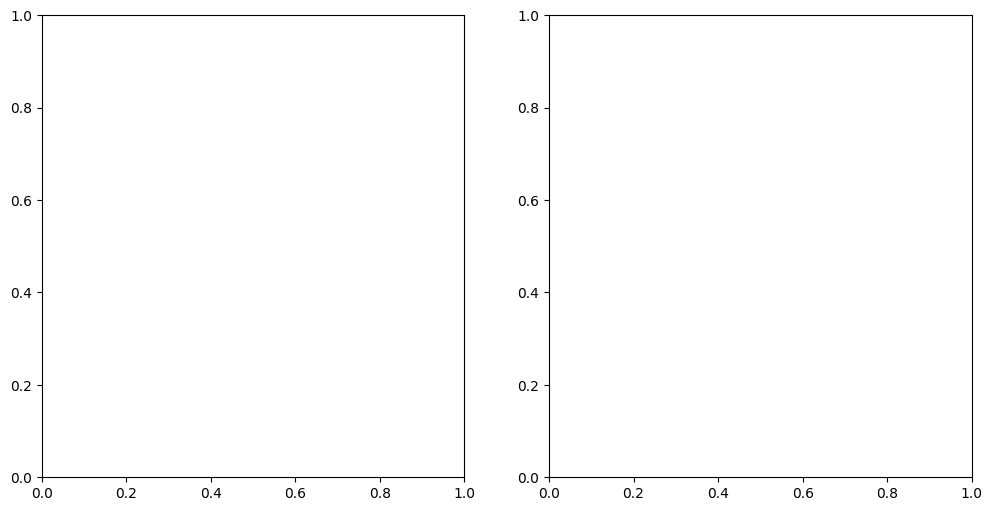

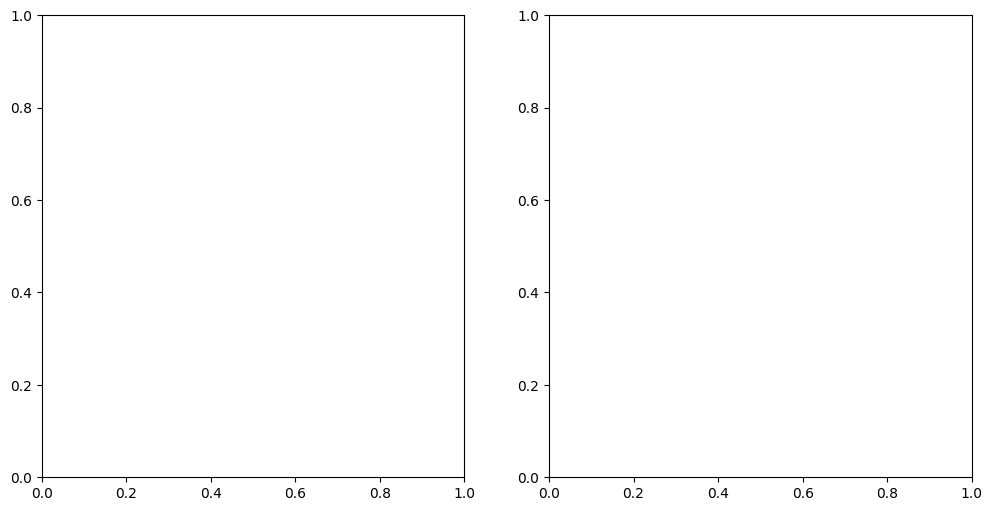

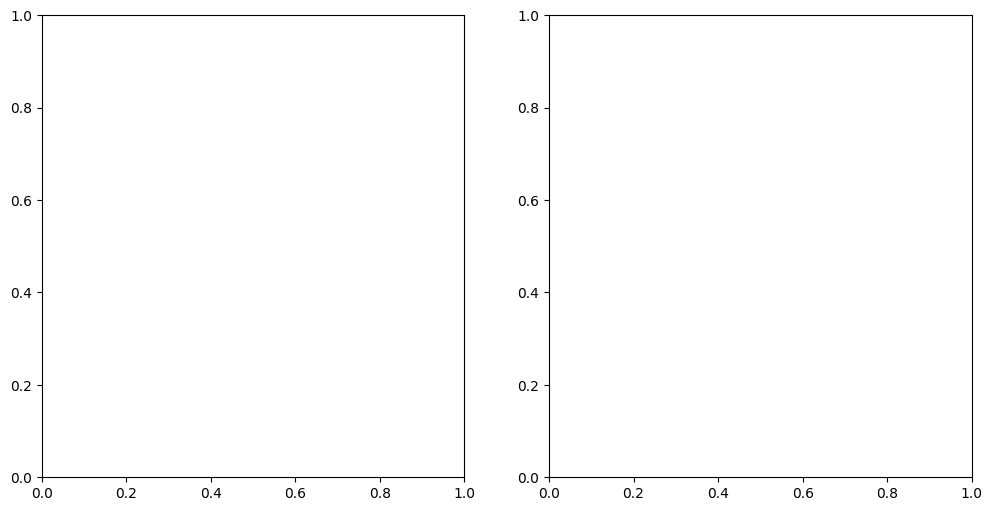

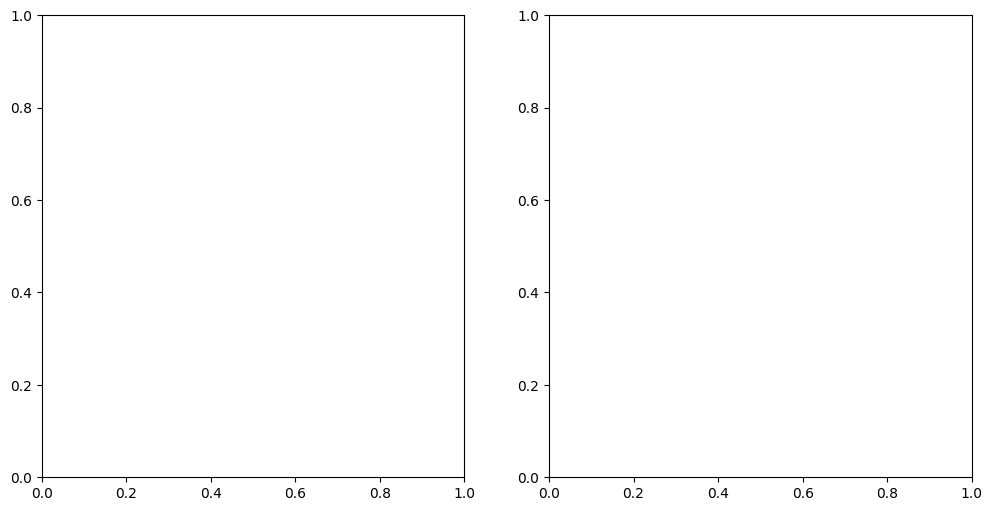

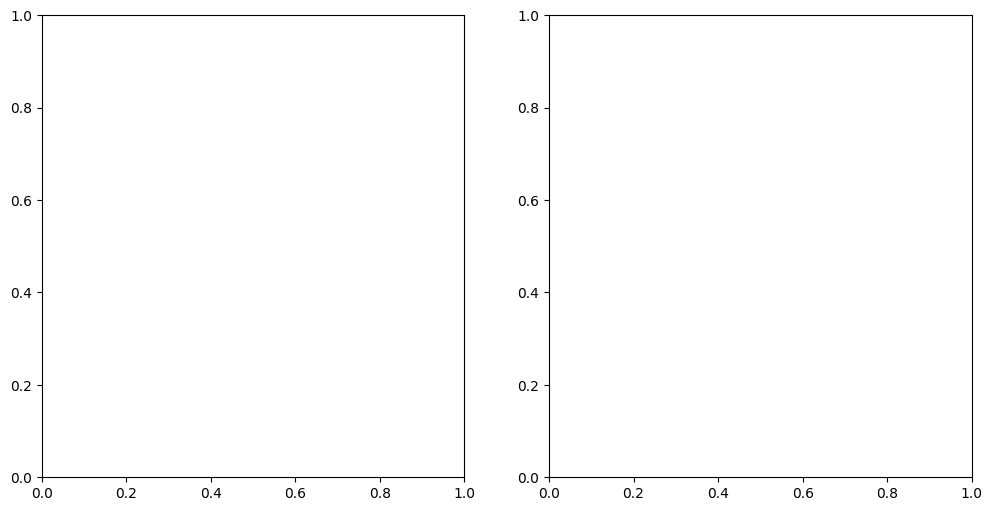

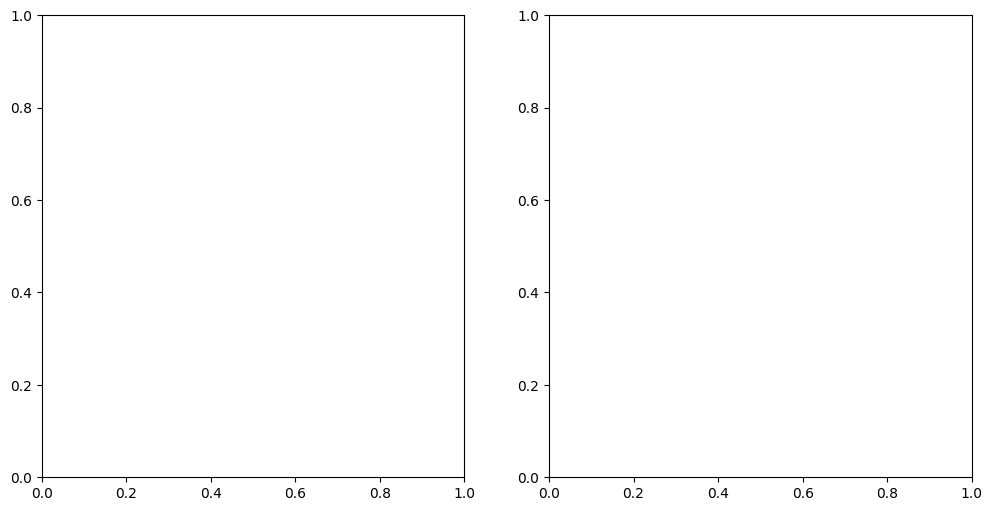

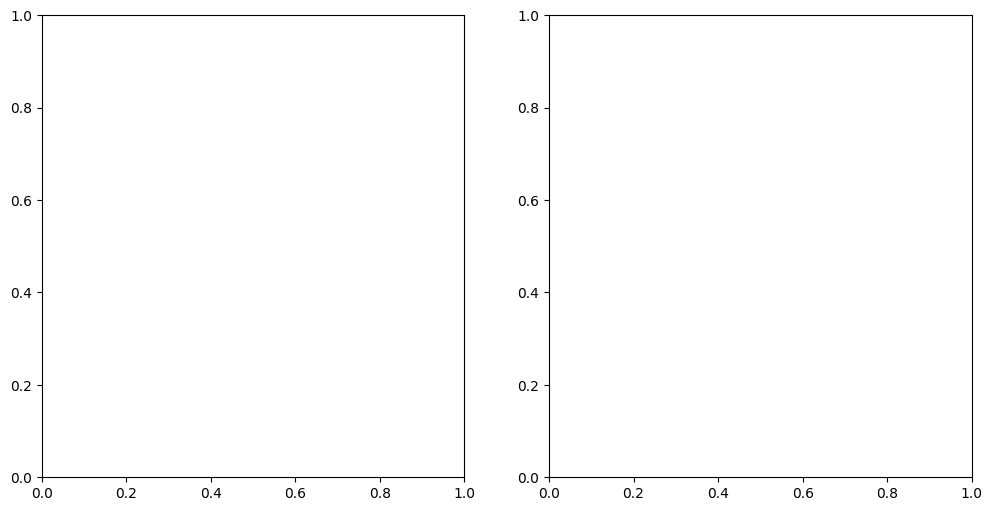

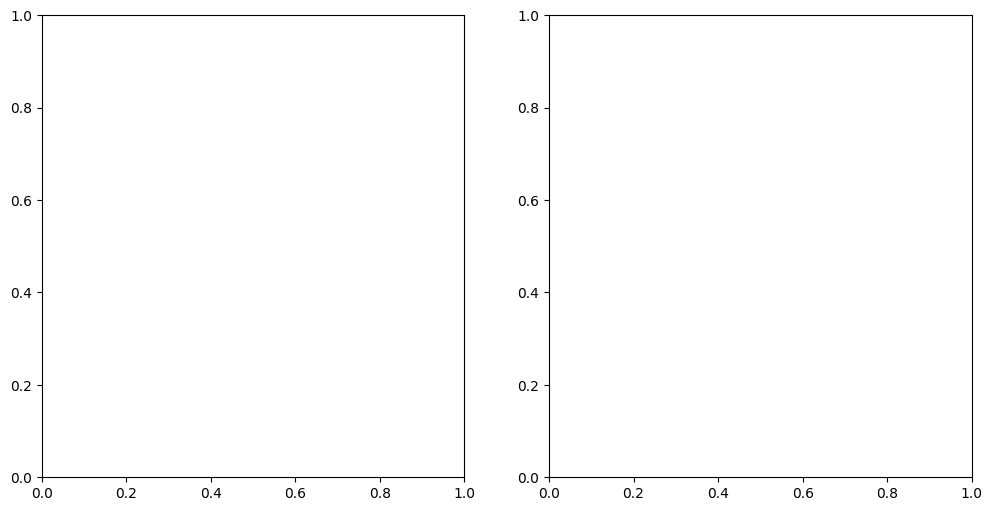

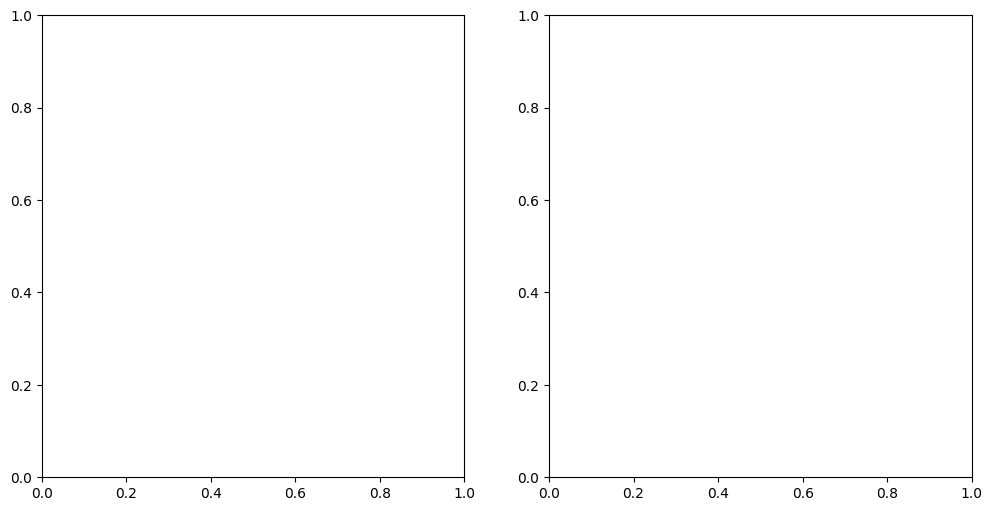

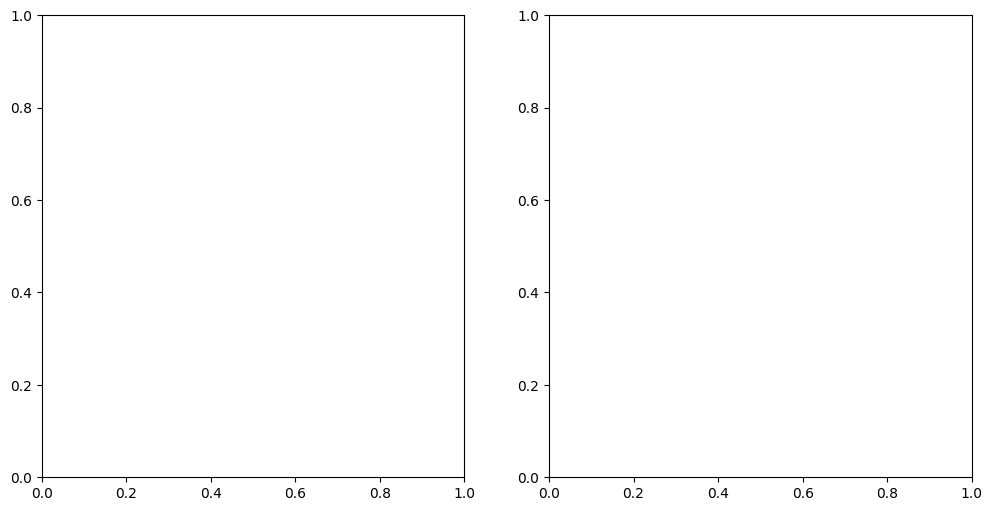

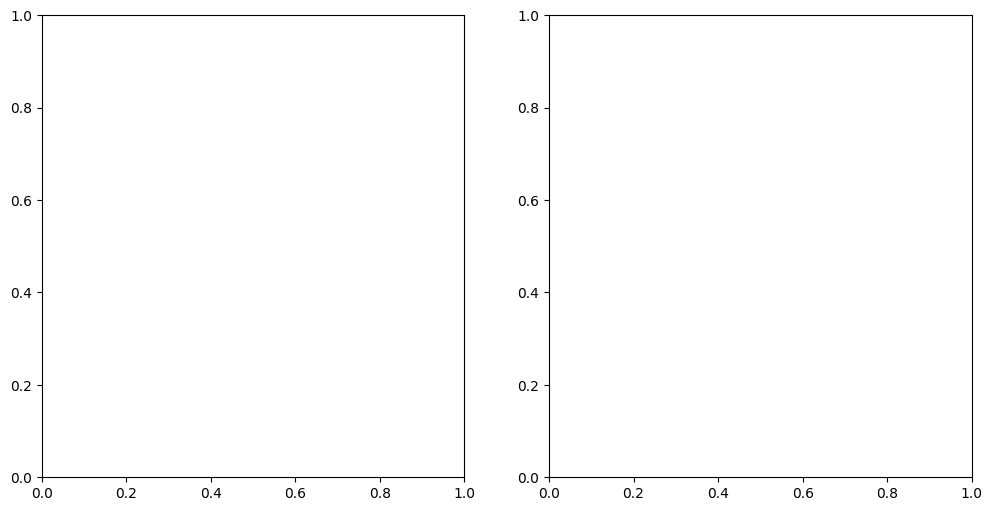

In [17]:
# 使用 session4 数据进行测试
base_dir = Path("/media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/spike_detection/new")
test_recording_path = base_dir.parent.parent / "data_generation" / "recording_neuropixels_session4.h5"
print(f"[INFO] 使用测试数据: {test_recording_path.name}")

train_tpr_path = base_dir / "train_tpr_dict.pkl"
if train_tpr_path.exists():
    with open(train_tpr_path, "rb") as f:
        train_tpr_dict = pickle.load(f)
else:
    print("[WARN] 找不到 train_tpr_dict.pkl，将尝试使用当前内存中的 tpr_dict。")
    train_tpr_dict = tpr_dict if "tpr_dict" in globals() else {}
    if not train_tpr_dict:
        raise FileNotFoundError("train_tpr_dict.pkl 未找到且内存中不存在 tpr_dict。")

recording_test_raw = se.MEArecRecordingExtractor(file_path=str(test_recording_path))
probe_session4 = recording_test_raw.get_probegroup()
probe_session4.set_global_device_channel_indices(range(384))
recording_test_raw = recording_test_raw.set_probegroup(probe_session4)
recording_test_f = spre.bandpass_filter(recording_test_raw, freq_min=300, freq_max=3000)
recording_test_f = spre.common_reference(recording_test_f, reference="global", operator="median")

spike_inf_session4 = pd.read_csv(base_dir.parent.parent / "data_generation" / "session_4_spike_inf.csv")
cluster_inf_session4 = pd.read_csv(base_dir.parent.parent / "data_generation" / "session_4_cluster_inf.csv")

device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 2048
chunk_size = 120000
window_size = 51
half_window = window_size // 2

print(f"[INFO] 推理将运行在 {device} 上，batch_size={batch_size}")

test_results = []
overall_counts = {
    "tp": 0,
    "fp": 0,
    "tn": 0,
    "fn": 0,
    "candidates": 0,
    "positives": 0,
    "predicted": 0,
    "total_true_spikes": 0,
}

for clique_id, clique in enumerate(cliques):
    print(f"\n[测试] 处理 clique {clique_id}")
    model_dir = base_dir / str(clique_id)
    if not model_dir.exists():
        print("  未找到模型目录，跳过。")
        continue

    trail_scores = train_tpr_dict.get(clique_id, [])
    if len(trail_scores) == 0:
        print("  无 TPR 记录，默认使用 trail_1。")
        best_trail = 1
    else:
        best_trail = int(np.argmax(np.array(trail_scores))) + 1

    model_path = model_dir / f"trail_{best_trail}.pth"
    if not model_path.exists():
        available_models = sorted(model_dir.glob("trail_*.pth"))
        if not available_models:
            print("  未找到任何模型文件，跳过。")
            continue
        model_path = available_models[-1]
        best_trail = int(model_path.stem.split("_")[-1])
        print(f"  指定模型缺失，改用 {model_path.name}")

    print(f"  使用模型: {model_path.name} (device={device})")
    model = torch.load(model_path, map_location=device, weights_only= False)
    model = model.to(device)
    model.eval()

    total_frames = recording_test_f.get_num_samples()
    candidate_total = 0
    positive_total = 0
    predicted_total = 0
    tp = tn = fp = fn = 0
    predicted_spike_times = []
    max_umap_samples = 100000
    fc3_samples = []
    gt_samples = []
    pred_samples = []
    total_activation_seen = 0

    channel_mask = probe_df["device_channel_indices"].isin(clique.device_channel_indices)
    clique_positions = probe_df.loc[channel_mask, ["x", "y"]].to_numpy()

    if clique_positions.size == 0:
        y_min = float(cluster_inf_session4["y"].min())
        y_max = float(cluster_inf_session4["y"].max())
    else:
        if clique_positions.shape[0] >= 3:
            hull = ConvexHull(clique_positions)
            hull_points = clique_positions[hull.vertices]
        else:
            hull_points = clique_positions
        y_min = float(hull_points[:, 1].min())
        y_max = float(hull_points[:, 1].max())

    margin = 60.0
    if y_max - y_min > 2 * margin:
        y_lower = y_min + margin
        y_upper = y_max - margin
    else:
        y_lower = y_min
        y_upper = y_max

    cluster_y = cluster_inf_session4["y"].to_numpy()
    cluster_ids = cluster_inf_session4["Neuron"].to_numpy()
    mask = (cluster_y >= y_lower) & (cluster_y <= y_upper)
    indices_within_range = cluster_ids[mask]
    spike_inf_temp = spike_inf_session4[spike_inf_session4["Neuron"].isin(indices_within_range)]
    total_real_spikes = len(spike_inf_temp)

    if total_real_spikes == 0:
        print("  目标范围内无真实 spike 记录，跳过。")
        continue

    frame_iterator = range(0, total_frames, chunk_size)
    for start_frame in tqdm(frame_iterator, desc=f"Clique {clique_id}", leave=False):
        end_frame = min(start_frame + chunk_size, total_frames)
        data_chunk = recording_test_f.get_traces(
            start_frame=start_frame,
            end_frame=end_frame,
            channel_ids=clique.device_channel_indices,
        )

        threshold_result = detect_local_minimum_in_window(
            data_chunk.T,
            std_multiplier=4,
            window_size=40,
        )

        if len(threshold_result) == 0:
            continue

        threshold_result = np.array(threshold_result) + start_frame
        valid_indices = threshold_result[
            (threshold_result >= start_frame + half_window + 1)
            & (threshold_result < end_frame - half_window)
        ]

        if valid_indices.size == 0:
            continue

        rel_indices = valid_indices - start_frame
        windows = np.stack(
            [
                data_chunk.T[:, rel_idx - half_window : rel_idx + half_window + 1]
                for rel_idx in rel_indices
            ],
            axis=0,
        ).astype(np.float32)

        labels = label_array1_based_on_array2(valid_indices, spike_inf_temp["time"], threshold=1)

        candidate_total += len(valid_indices)
        positive_total += int(labels.sum())

        dataset_chunk = CustomDataset(windows, labels)
        loader_chunk = DataLoader(dataset_chunk, batch_size=batch_size, shuffle=False)

        chunk_probs = []
        chunk_truth = []
        with torch.no_grad():
            for batch_data, batch_labels in loader_chunk:
                batch_data_device = batch_data.to(device)
                outputs, fc3_batch = model(batch_data_device, return_fc3=True)
                probs = outputs.squeeze(1).detach().cpu().numpy()
                chunk_probs.append(probs)

                labels_np = batch_labels.numpy()
                chunk_truth.append(labels_np)

                fc3_np = fc3_batch.detach().cpu().numpy()
                preds_np = (probs > 0.5).astype(int)
                labels_int = labels_np.astype(int)

                for feature_vec, gt_val, pred_val in zip(fc3_np, labels_int, preds_np):
                    total_activation_seen += 1
                    if len(fc3_samples) < max_umap_samples:
                        fc3_samples.append(feature_vec)
                        gt_samples.append(int(gt_val))
                        pred_samples.append(int(pred_val))
                    else:
                        replace_idx = np.random.randint(0, total_activation_seen)
                        if replace_idx < max_umap_samples:
                            fc3_samples[replace_idx] = feature_vec
                            gt_samples[replace_idx] = int(gt_val)
                            pred_samples[replace_idx] = int(pred_val)

        chunk_probs = np.concatenate(chunk_probs)
        chunk_truth = np.concatenate(chunk_truth).astype(int)
        chunk_pred = (chunk_probs > 0.5).astype(int)

        predicted_total += int(chunk_pred.sum())
        predicted_spike_times.extend(valid_indices[chunk_pred == 1])

        tp += int(np.sum((chunk_pred == 1) & (chunk_truth == 1)))
        tn += int(np.sum((chunk_pred == 0) & (chunk_truth == 0)))
        fp += int(np.sum((chunk_pred == 1) & (chunk_truth == 0)))
        fn += int(np.sum((chunk_pred == 0) & (chunk_truth == 1)))

        del windows, dataset_chunk, loader_chunk, chunk_probs, chunk_truth, chunk_pred
        if device == "cuda":
            torch.cuda.empty_cache()

    if candidate_total == 0:
        print("  未检测到候选 spike，跳过。")
        continue

    detection_recall = positive_total / total_real_spikes * 100 if total_real_spikes > 0 else 0
    detection_precision = positive_total / candidate_total * 100 if candidate_total > 0 else 0

    precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / candidate_total * 100 if candidate_total > 0 else 0
    f1_score = 2 * tp / (2 * tp + fp + fn) * 100 if (2 * tp + fp + fn) > 0 else 0

    if len(fc3_samples) > 1:
        fc3_array = np.array(fc3_samples)
        reducer = umap.UMAP(n_components=2, random_state=42)
        embedding = reducer.fit_transform(fc3_array)

        gt_array = np.array(gt_samples, dtype=int)
        pred_array = np.array(pred_samples, dtype=int)

        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        cmap = ListedColormap(["lightgray", "orange"])
        umap_path = model_dir / f"clique_{clique_id}_fc3_umap.pdf"
        with PdfPages(umap_path) as pdf:
            plt.figure(figsize=(8, 8))
            plt.scatter(embedding[:, 0], embedding[:, 1], c=gt_array, cmap=cmap, alpha=1, s = 1)
            plt.grid(False)
            plt.xticks([])
            plt.yticks([])
            pdf.savefig()  
            plt.close()

            plt.figure(figsize=(8, 8))
            plt.scatter(embedding[:, 0], embedding[:, 1], c=pred_array, cmap=cmap, alpha=1, s = 1)
            plt.grid(False)
            plt.xticks([])
            plt.yticks([])
            pdf.savefig()  
            plt.close()
    else:
        print("  样本数不足，跳过 UMAP 可视化。")

    np.save(model_dir / "session4_predicted_spike_times.npy", np.array(predicted_spike_times, dtype=np.int64))

    print(
        "  检测候选: {:,} | 匹配真实: {:,}/{:,} | 检测召回 {:.2f}% | 检测精确 {:.2f}%".format(
            candidate_total,
            positive_total,
            total_real_spikes,
            detection_recall,
            detection_precision,
        )
    )
    print(
        "  分类指标 -> 精确 {:.2f}% | 召回 {:.2f}% | 特异性 {:.2f}% | F1 {:.2f}% | 预测spike {:,}".format(
            precision,
            recall,
            specificity,
            f1_score,
            predicted_total,
        )
    )

    test_results.append({
        "clique_id": clique_id,
        "best_trail": best_trail,
        "candidates": candidate_total,
        "detected_true_spikes": positive_total,
        "total_true_spikes": total_real_spikes,
        "detection_recall_%": detection_recall,
        "detection_precision_%": detection_precision,
        "predicted_spikes": predicted_total,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "precision_%": precision,
        "recall_%": recall,
        "specificity_%": specificity,
        "accuracy_%": accuracy,
        "f1_%": f1_score,
    })

    overall_counts["tp"] += tp
    overall_counts["fp"] += fp
    overall_counts["tn"] += tn
    overall_counts["fn"] += fn
    overall_counts["candidates"] += candidate_total
    overall_counts["positives"] += positive_total
    overall_counts["predicted"] += predicted_total
    overall_counts["total_true_spikes"] += total_real_spikes

if not test_results:
    raise RuntimeError("未能生成任何测试结果，请检查模型文件与数据路径。")

test_results_df = pd.DataFrame(test_results)
display(test_results_df)

output_path = base_dir / "session4_test_metrics.csv"
test_results_df.to_csv(output_path, index=False)
print(f"\n[INFO] 测试指标已保存至: {output_path}")

tp = overall_counts["tp"]
fp = overall_counts["fp"]
tn = overall_counts["tn"]
fn = overall_counts["fn"]
candidates = overall_counts["candidates"]
positives = overall_counts["positives"]
predicted = overall_counts["predicted"]
total_true = overall_counts["total_true_spikes"]

overall_metrics = {
    "precision_%": tp / (tp + fp) * 100 if (tp + fp) > 0 else 0,
    "recall_%": tp / (tp + fn) * 100 if (tp + fn) > 0 else 0,
    "specificity_%": tn / (tn + fp) * 100 if (tn + fp) > 0 else 0,
    "accuracy_%": (tp + tn) / candidates * 100 if candidates > 0 else 0,
    "f1_%": 2 * tp / (2 * tp + fp + fn) * 100 if (2 * tp + fp + fn) > 0 else 0,
    "detection_recall_%": positives / total_true * 100 if total_true > 0 else 0,
    "detection_precision_%": positives / candidates * 100 if candidates > 0 else 0,
    "candidates": candidates,
    "detected_true_spikes": positives,
    "total_true_spikes": total_true,
    "predicted_spikes": predicted,
}

display(pd.DataFrame([overall_metrics]))

